# Машинное обучение. Курсовая работа

Датасет "Support Ticket Priority Dataset (50k)" представляет собой синтетический, но реалистично смоделированный набор данных, имитирующий работу IT-сервисной дески (Service Desk) или службы поддержки компании. Датасет содержит 50 000 записей об обращениях (тикетах) в службу поддержки. 

## Предобработка и анализ данных

In [1]:
import numpy as np 
import pandas as pd 

df = pd.read_csv("../data/Support_tickets.csv")
df.head(5)

,ticket_id,day_of_week,day_of_week_num,company_id,company_size,company_size_cat,industry,industry_cat,customer_tier,customer_tier_cat,...,downtime_min,payment_impact_flag,security_incident_flag,data_loss_flag,has_runbook,customer_sentiment,customer_sentiment_cat,description_length,priority,priority_cat
0,1000000000,Wed,3,100015,Small,1,media,7,Basic,1,...,6,0,0,0,0,neutral,2,227,low,1
1,1000000001,Sat,6,100023,Small,1,healthcare,5,Basic,1,...,2,0,0,0,0,neutral,2,461,low,1
2,1000000002,Mon,1,100012,Small,1,gaming,4,Basic,1,...,0,0,0,0,1,positive,3,306,low,1
3,1000000003,Wed,3,100003,Small,1,media,7,Plus,2,...,16,0,0,0,1,neutral,2,363,medium,2
4,1000000004,Mon,1,100019,Small,1,ecommerce,2,Plus,2,...,6,0,0,0,0,neutral,2,442,low,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ticket_id               50000 non-null  int64  
 1   day_of_week             50000 non-null  object 
 2   day_of_week_num         50000 non-null  int64  
 3   company_id              50000 non-null  int64  
 4   company_size            50000 non-null  object 
 5   company_size_cat        50000 non-null  int64  
 6   industry                50000 non-null  object 
 7   industry_cat            50000 non-null  int64  
 8   customer_tier           50000 non-null  object 
 9   customer_tier_cat       50000 non-null  int64  
 10  org_users               50000 non-null  int64  
 11  region                  50000 non-null  object 
 12  region_cat              50000 non-null  int64  
 13  past_30d_tickets        50000 non-null  int64  
 14  past_90d_incidents      50000 non-null

In [3]:
# В датасете категориальные признаки уже имеют закодированные числовые признаки,
# поэтому копируем датасет, но только с числовыми признаками
df.drop(columns='ticket_id', inplace=True)
print('\nDropped the non-informative identifying column: row_id')
num_df = df.select_dtypes(include=["number"]).copy()
num_df.info()


Dropped the non-informative identifying column: row_id
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day_of_week_num         50000 non-null  int64  
 1   company_id              50000 non-null  int64  
 2   company_size_cat        50000 non-null  int64  
 3   industry_cat            50000 non-null  int64  
 4   customer_tier_cat       50000 non-null  int64  
 5   org_users               50000 non-null  int64  
 6   region_cat              50000 non-null  int64  
 7   past_30d_tickets        50000 non-null  int64  
 8   past_90d_incidents      50000 non-null  int64  
 9   product_area_cat        50000 non-null  int64  
 10  booking_channel_cat     50000 non-null  int64  
 11  reported_by_role_cat    50000 non-null  int64  
 12  customers_affected      50000 non-null  int64  
 13  error_rate_pct          50000 non-n

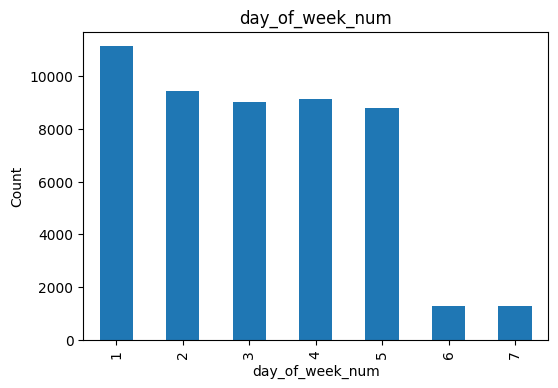

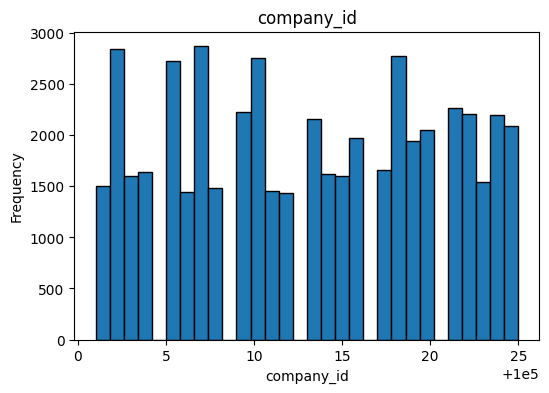

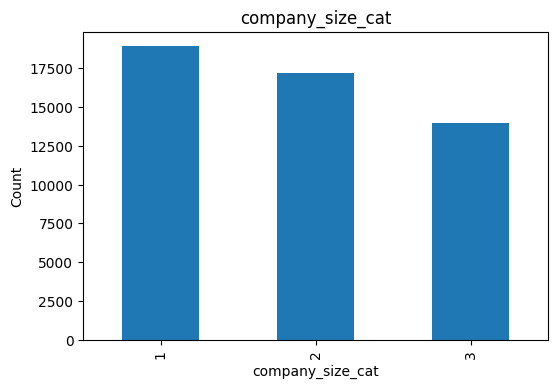

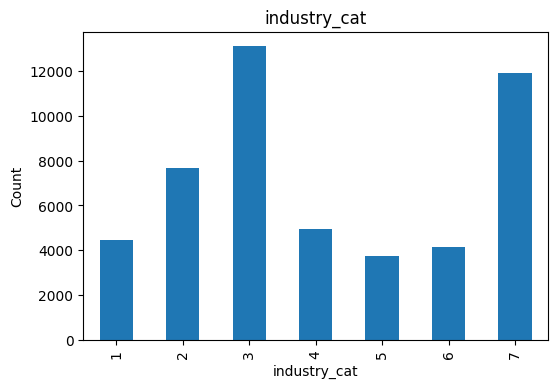

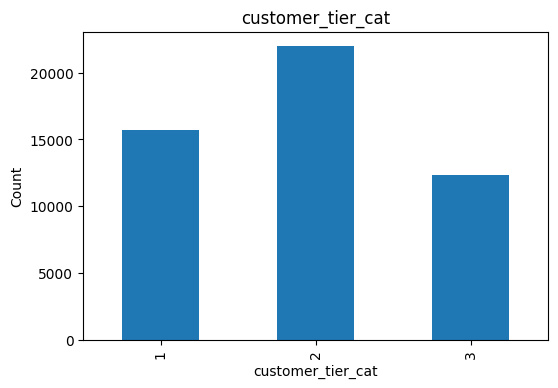

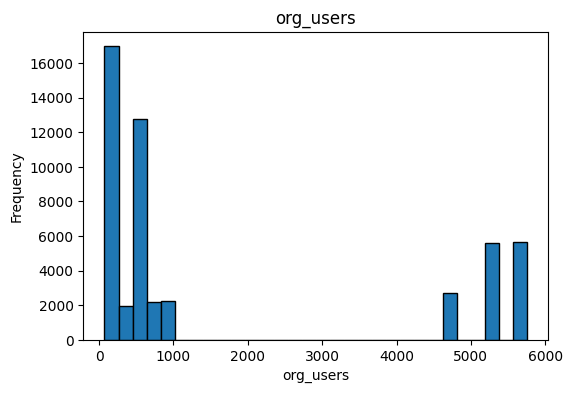

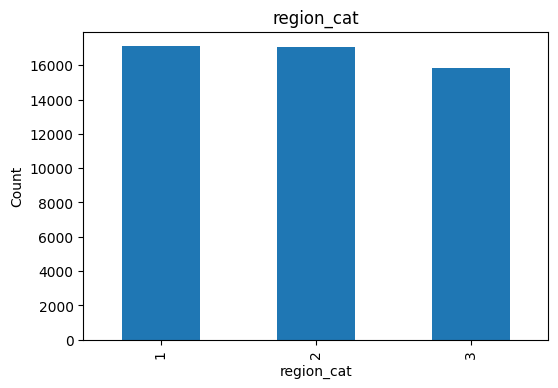

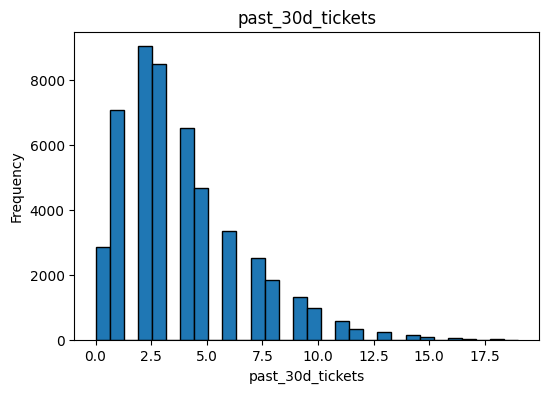

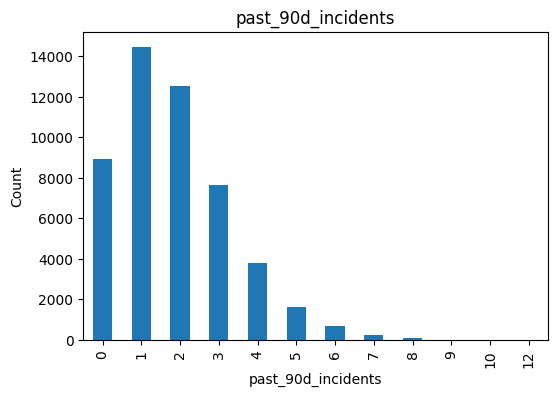

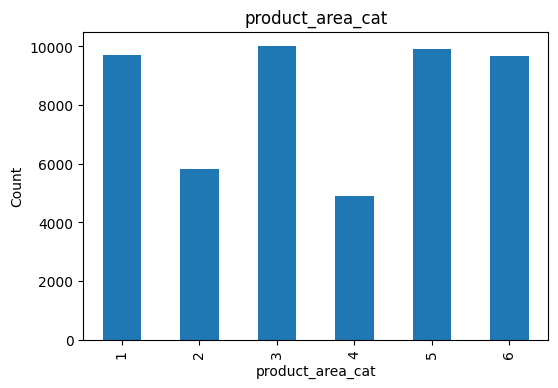

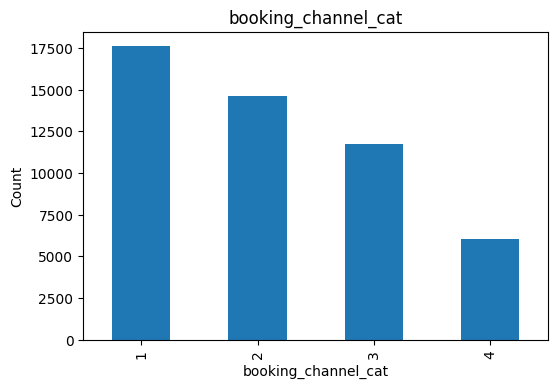

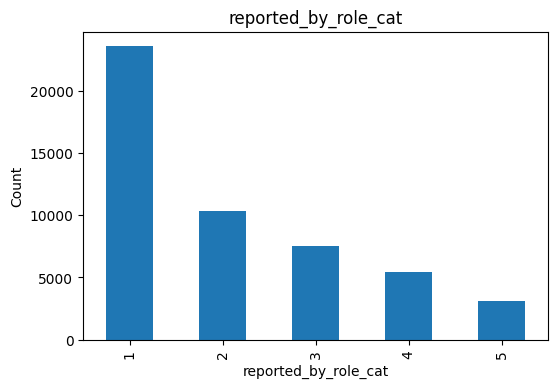

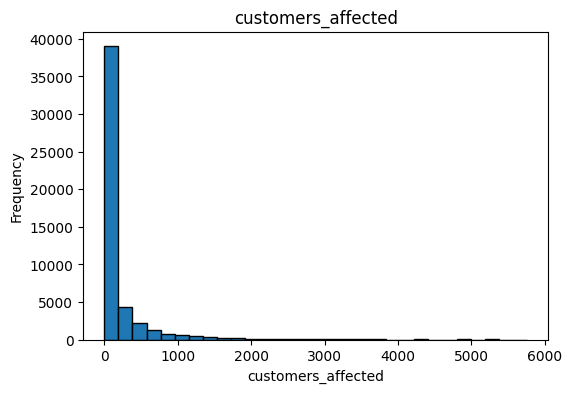

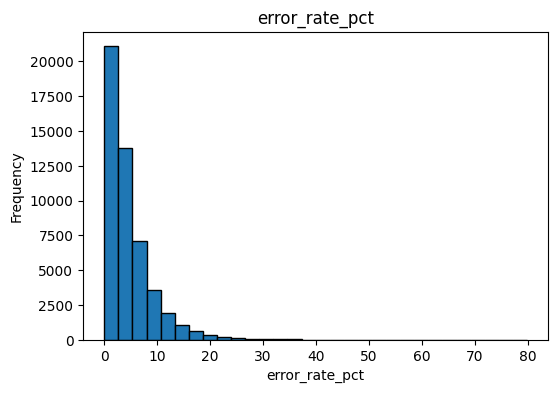

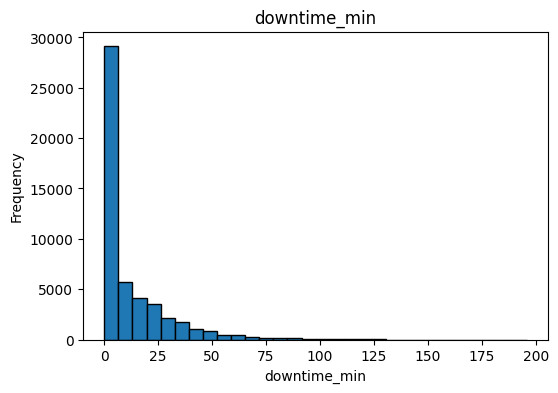

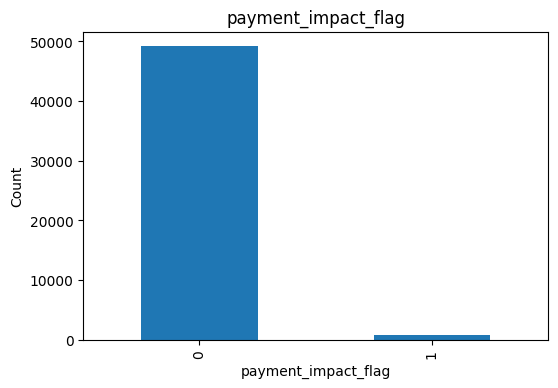

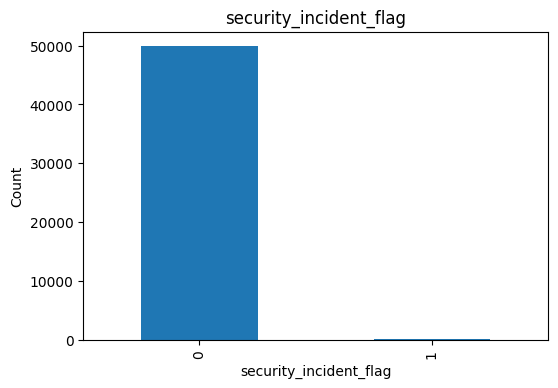

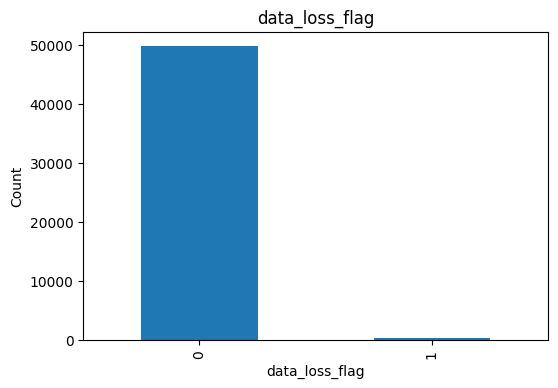

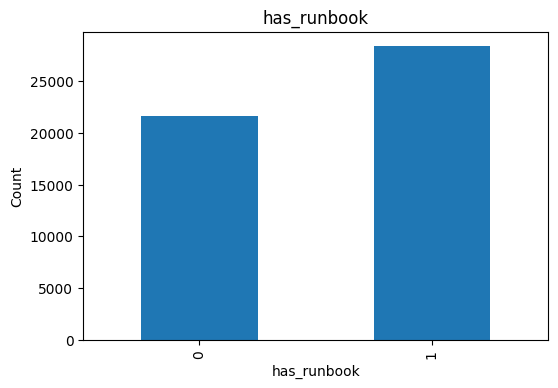

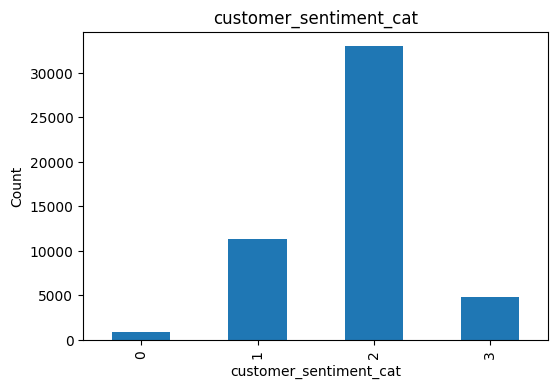

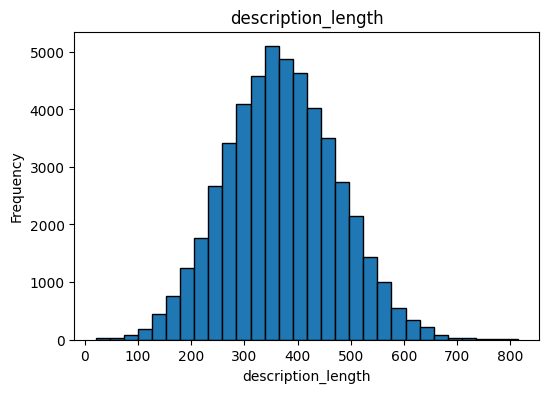

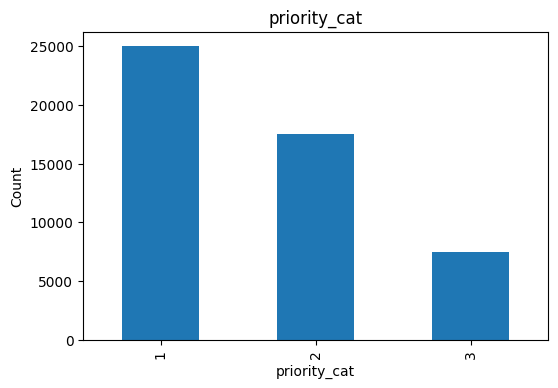

In [4]:
# Гистограммы числовых признаков
import matplotlib.pyplot as plt

for col in num_df.columns:
    plt.figure(figsize=(6,4))
    if num_df[col].nunique() <= 15:
        num_df[col].value_counts().sort_index().plot(kind="bar")
        plt.ylabel("Count")
    else:
        num_df[col].plot(kind="hist", bins=30, edgecolor="black")
        plt.ylabel("Frequency")
    plt.title(col)
    plt.xlabel(col)
    plt.show()

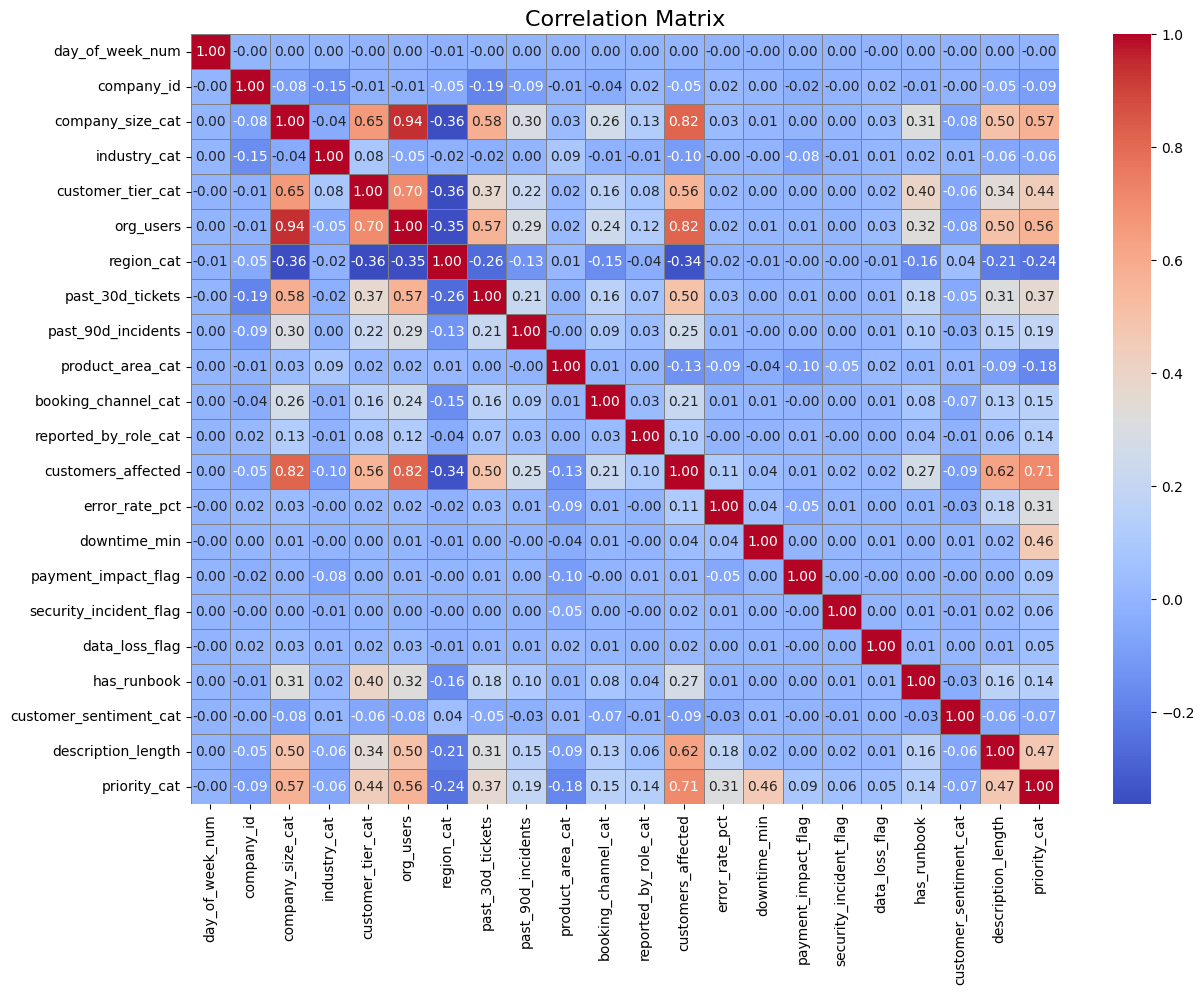

In [5]:
# Тепловая карта корелляций числовых признаков
import seaborn as sns

corr = num_df.corr(numeric_only=True, method='spearman')

plt.figure(figsize=(14,10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="gray",
    cbar=True
)
plt.title("Correlation Matrix", fontsize=16)
plt.show()

По тепловой карте видно, что категориальный признак размера компании сильно (0.89) кореллирует с параметром org_users, поэтому его можно убрать за избыточностью

In [6]:
num_df.drop(columns='org_users', inplace=True)

## Работа с моделями

Релевантные метрики для оценки модели:
- Accuracy: стандартная оценка точности
- F1-score (macro): Основная метрика. Она учитывает как точность (precision), так и полноту (recall) и хорошо работает с дисбалансом.
- Confusion Matrix (Матрица ошибок): Поможет понять, какие классы модель путает чаще всего.

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

import shap
shap.initjs()

import tuna

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# Выделяем приоритет как целевой признак
X = num_df.drop(columns=["priority_cat"])
y = num_df["priority_cat"].astype(int) - 1 

# Разбиваем на тренировочную и тестовую с y в качестве аргумента stratify для баланса подвыборок
# Валидационная не нужна, потому что будем проводить кросс-валидацию
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42, stratify=y_test)

In [9]:
# Создаем список моделей, которые хотим протестировать и запускаем Optuna оптимизацию гиперпараметров
# OS будет хранить все лучшие обученные модели среди своего класса (1 LogisticRegression, 1 RandomForestClassifier и т.д.)
model_classes = ['HistGradientBoostingClassifier', 'LogisticRegression','RandomForestClassifier','XGBClassifier']

OS = tuna.OptunaSearchCV(model_classes)
OS.fit(X_train, y_train, X_val, y_val, n_trials=50, n_startup_trials=10)
OS.results_df.to_csv('../results/results.csv')


HistGradientBoostingClassifier hyperoptimization


Best trial: 47. Best value: 0.97041: 100%|██████████| 50/50 [02:00<00:00,  2.40s/it] 



LogisticRegression hyperoptimization


Best trial: 2. Best value: 0.771431:  20%|██        | 10/50 [01:57<02:10,  3.27s/it] 

[W 2025-12-23 17:36:28,179] The parameter `solver_l2` in Trial#25 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 2. Best value: 0.771431:  22%|██▏       | 11/50 [01:58<01:32,  2.37s/it]

[W 2025-12-23 17:36:28,523] The parameter `solver_l2` in Trial#26 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 2. Best value: 0.771431:  24%|██▍       | 12/50 [02:09<03:15,  5.14s/it]

[W 2025-12-23 17:36:39,993] The parameter `solver_l2` in Trial#27 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 2. Best value: 0.771431:  26%|██▌       | 13/50 [02:31<06:17, 10.20s/it]

[W 2025-12-23 17:37:01,840] The parameter `solver_l2` in Trial#28 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 2. Best value: 0.771431:  28%|██▊       | 14/50 [03:00<09:34, 15.96s/it]

[W 2025-12-23 17:37:31,104] The parameter `solver_l2` in Trial#29 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 2. Best value: 0.771431:  30%|███       | 15/50 [03:02<06:53, 11.83s/it]

[W 2025-12-23 17:37:33,352] The parameter `solver_l2` in Trial#30 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 2. Best value: 0.771431:  32%|███▏      | 16/50 [03:07<05:29,  9.70s/it]

[W 2025-12-23 17:37:38,130] The parameter `solver_l2` in Trial#31 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 2. Best value: 0.771431:  34%|███▍      | 17/50 [03:10<04:08,  7.52s/it]

[W 2025-12-23 17:37:40,567] The parameter `solver_l2` in Trial#32 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 2. Best value: 0.771431:  36%|███▌      | 18/50 [03:10<02:53,  5.43s/it]

[W 2025-12-23 17:37:41,124] The parameter `solver_l2` in Trial#33 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 2. Best value: 0.771431:  38%|███▊      | 19/50 [03:11<02:00,  3.89s/it]

[W 2025-12-23 17:37:41,449] The parameter `solver_l2` in Trial#34 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 2. Best value: 0.771431:  40%|████      | 20/50 [03:15<02:03,  4.12s/it]

[W 2025-12-23 17:37:46,089] The parameter `solver_l2` in Trial#35 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 2. Best value: 0.771431:  42%|████▏     | 21/50 [03:20<02:04,  4.29s/it]

[W 2025-12-23 17:37:50,775] The parameter `solver_l2` in Trial#36 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 2. Best value: 0.771431:  44%|████▍     | 22/50 [03:23<01:53,  4.04s/it]

[W 2025-12-23 17:37:54,251] The parameter `solver_l2` in Trial#37 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 2. Best value: 0.771431:  46%|████▌     | 23/50 [03:25<01:28,  3.28s/it]

[W 2025-12-23 17:37:55,761] The parameter `solver_l2` in Trial#38 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 2. Best value: 0.771431:  50%|█████     | 25/50 [03:25<01:00,  2.41s/it]

[W 2025-12-23 17:37:56,118] The parameter `solver_l2` in Trial#39 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-12-23 17:37:56,181] The parameter `solver_l2` in Trial#40 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 2. Best value: 0.771431:  52%|█████▏    | 26/50 [03:32<01:10,  2.95s/it]

[W 2025-12-23 17:38:03,286] The parameter `solver_l2` in Trial#41 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 27. Best value: 0.771826:  54%|█████▍    | 27/50 [03:37<01:15,  3.29s/it]

[W 2025-12-23 17:38:07,637] The parameter `solver_l2` in Trial#42 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 27. Best value: 0.771826:  56%|█████▌    | 28/50 [04:00<03:09,  8.60s/it]

[W 2025-12-23 17:38:31,187] The parameter `solver_l2` in Trial#43 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 27. Best value: 0.771826:  58%|█████▊    | 29/50 [04:05<02:38,  7.55s/it]

[W 2025-12-23 17:38:35,942] The parameter `solver_l2` in Trial#44 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 27. Best value: 0.771826:  60%|██████    | 30/50 [04:18<03:00,  9.02s/it]

[W 2025-12-23 17:38:48,738] The parameter `solver_l2` in Trial#45 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 30. Best value: 0.773423:  62%|██████▏   | 31/50 [04:20<02:16,  7.20s/it]

[W 2025-12-23 17:38:51,396] The parameter `solver_l2` in Trial#46 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 30. Best value: 0.773423:  66%|██████▌   | 33/50 [04:24<01:15,  4.42s/it]

[W 2025-12-23 17:38:54,797] The parameter `solver_l2` in Trial#48 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


Best trial: 30. Best value: 0.773423: 100%|██████████| 50/50 [05:38<00:00,  6.78s/it]



RandomForestClassifier hyperoptimization


Best trial: 40. Best value: 0.936704: 100%|██████████| 50/50 [18:04<00:00, 21.68s/it] 



XGBClassifier hyperoptimization


Best trial: 49. Best value: 0.974311: 100%|██████████| 50/50 [02:12<00:00,  2.64s/it]


Prediction Accuracy: 0.9806666666666667
F1: 0.9773900459806096


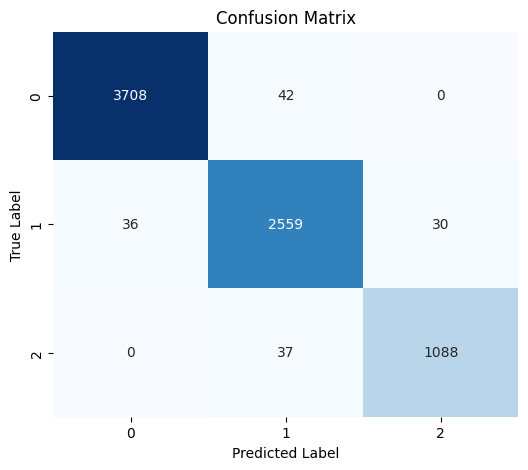

In [20]:
# {'learning_rate': 0.31183717353699403, 'max_depth': 3, 'min_child_weight': 1.9092149748498457, 'gamma': 0.5776879488090906, 
# 'reg_alpha': 1.3036369770875613, 'reg_lambda': 1.4919232047483344, 'subsample': 0.7181065219444565, 'colsample_bytree': 0.9722126862480334}"
model = XGBClassifier(n_estimators=500,learning_rate=0.3,max_depth=3,min_child_weight=1.9,gamma=0.57,reg_alpha=1.3,reg_lambda=1.5,subsample=0.72,
                      colsample_bytree=0.97, objective="multi:softprob",eval_metric="mlogloss",tree_method="hist",)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
print('Prediction Accuracy:', accuracy)
print('F1:', f1)

cmatrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cmatrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

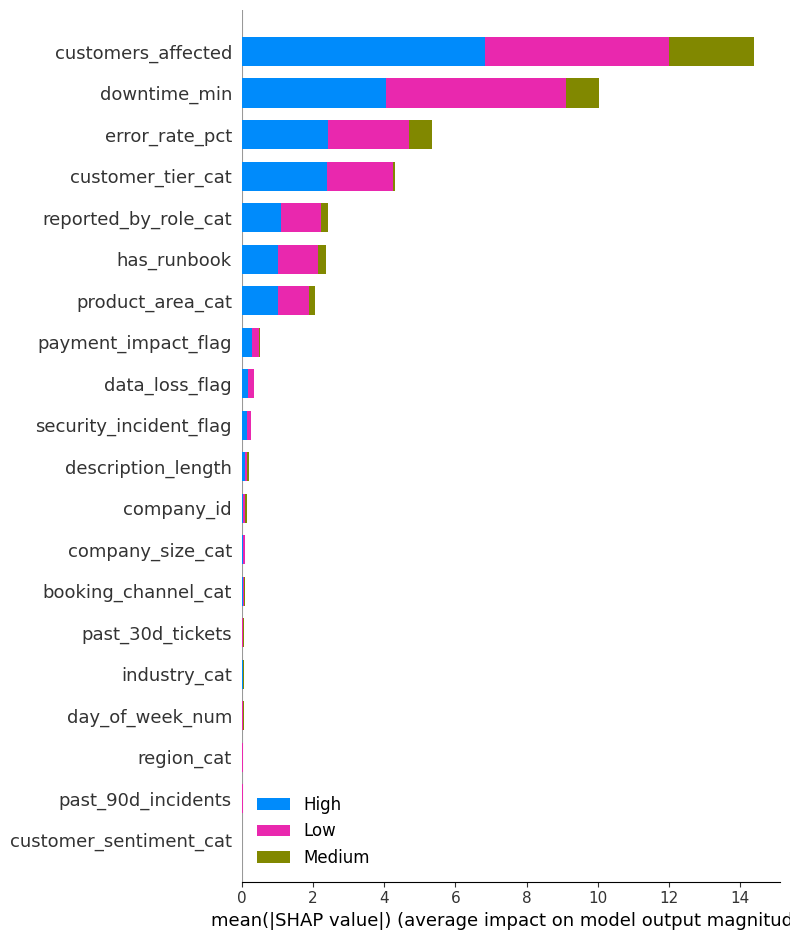

In [84]:
X_explain = X_train.iloc[:100]

feature_names = list(num_df.columns)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_explain)
shap_importance = np.abs(shap_values).mean(axis=0)
shap_exp = shap.Explanation(values=shap_values, base_values=explainer.expected_value, data=X_test,
                            feature_names=feature_names)

#shap.summary_plot(shap_values, X_explain, plot_type="dot")

shap.summary_plot(shap_values, X_explain, plot_type="bar", class_names=['Low', 'Medium', 'High'])
